In [8]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from src.config import US_TICKERS, INDIA_TICKERS, PROCESSED_DATA_DIR, RAW_DATA_DIR
from src.data_utils import(
    download_prices,
    compute_returns,
    filter_tickers,
    build_portfolio,
    save_panel,
)

RAW_DATA_DIR.mkdir(parents = True, exist_ok = True)
PROCESSED_DATA_DIR.mkdir(parents = True, exist_ok = True)

In [3]:
us_close = download_prices(US_TICKERS)
india_close = download_prices(INDIA_TICKERS)

print(f"US prices: {us_close.shape}")
print(f"India prices: {india_close.shape}")

US prices: (4024, 30)
India prices: (3950, 30)


In [4]:
us_returns = filter_tickers(compute_returns(us_close))
india_returns = filter_tickers(compute_returns(india_close))

print(f"US returns: {us_returns.shape}")
print(f"India returns: {india_returns.shape}")

US returns: (4023, 30)
India returns: (3949, 30)


In [5]:
us_portfolio = build_portfolio(us_returns)
india_portfolio = build_portfolio(india_returns)

print(f"US portfolio: {len(us_portfolio)} days")
print(f"India portfolio: {len(india_portfolio)} days")

US portfolio: 4023 days
India portfolio: 3949 days


                      US      India
Annual return     0.1137     0.1496
Annual vol        0.1676     0.1503
Skew             -0.7196    -1.0126
Kurtosis         18.1766    14.2986
Min daily        -0.1268    -0.1267
Max daily         0.1037     0.0808
N obs          4023.0000  3949.0000


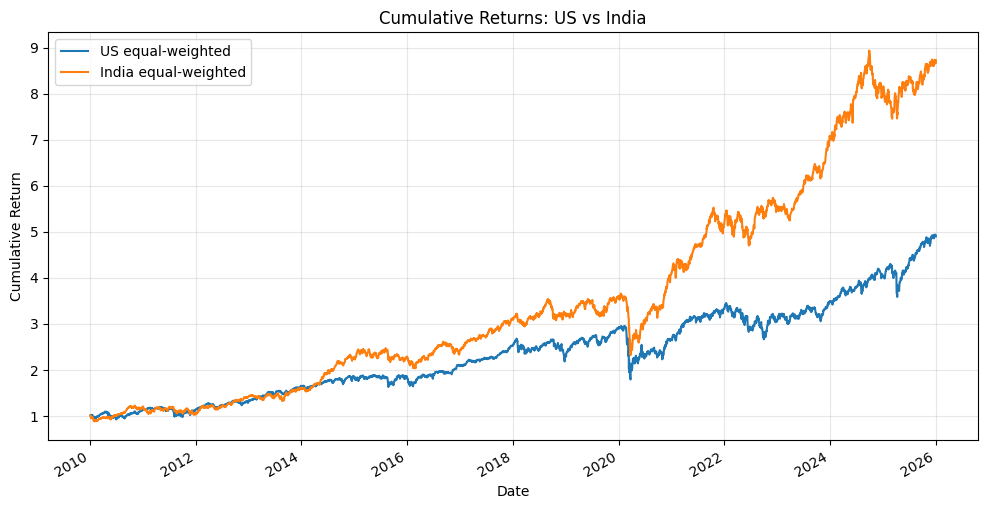

In [6]:
stats = pd.DataFrame({
    "US": [us_portfolio.mean() * 252, us_portfolio.std() * np.sqrt(252),
           us_portfolio.skew(), us_portfolio.kurtosis(),
           us_portfolio.min(), us_portfolio.max(), len(us_portfolio)],
    
    "India": [india_portfolio.mean() * 252, india_portfolio.std() * np.sqrt(252),
              india_portfolio.skew(), india_portfolio.kurtosis(),
              india_portfolio.min(), india_portfolio.max(), len(india_portfolio)],
    
}, index = ["Annual return", "Annual vol", "Skew", "Kurtosis", "Min daily", "Max daily", "N obs"])

print(stats.round(4))

fig, ax = plt.subplots(figsize = (12,6))
(1 + us_portfolio).cumprod().plot(ax = ax, label = "US equal-weighted")
(1+ india_portfolio).cumprod().plot(ax = ax, label = "India equal-weighted")

ax.legend()
ax.set_title("Cumulative Returns: US vs India")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.grid(alpha = 0.3)
plt.show()

In [7]:
save_panel(us_returns, PROCESSED_DATA_DIR / "us_returns.csv")
save_panel(india_returns, PROCESSED_DATA_DIR / "india_returns.csv")
save_panel(us_portfolio.to_frame(), PROCESSED_DATA_DIR / "us_portfolio.csv")
save_panel(india_portfolio.to_frame(), PROCESSED_DATA_DIR / "india_portfolio.csv")

print("Saved 4 CSVs to", PROCESSED_DATA_DIR)

Saved 4 CSVs to c:\Users\benph\Code\MFRM Project\market_risk_var\data\processed


## Output files

- us_returns.parquet — Daily log returns, dates × tickers (US)
- india_returns.parquet — Daily log returns, dates × tickers (India)
- us_portfolio.parquet — Daily equal-weighted portfolio return (US)
- india_portfolio.parquet — Daily equal-weighted portfolio return (India)

All returns are log returns (close-to-close). Portfolio returns are cross-sectional means with daily rebalancing.